# TP Graph

## First part : Spectral Graph Theory

In this TP, you will apply what we've seen in the graph neural network course. The TP can be done on [io.ensea.fr](https://io.ensea.fr), on you own computer, or in worst case, on google colab (least prefered).

In the first section of this TP, you will apply spectral filtering on a graph. A set of libraries that you might need is given in the following cell.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import networkx
from matplotlib import cm

In [1]:
!pip install networkx
!apt-get install -y graphviz libgraphviz-dev
!pip install pygraphviz
!pip install torch

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
libgraphviz-dev is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


 First, start by generating a graph (any kind) and extract its Laplacian. You may use the [networkx](https://networkx.org/) library to generate a random graph, or directly compute an adjacency matrix. The generated graph do not need to be too big, around 15 nodes should be okay. Remember that the Laplacian L is defined as : $L = D-A$

Also prepare the signal on you graph, by creating the H vector where one node is equal to 1, and the other ones are equal to 0

Finally, draw the graph you generated. To do so, you can use the [drawing](https://networkx.org/documentation/stable/reference/drawing.html) functions of networkx.

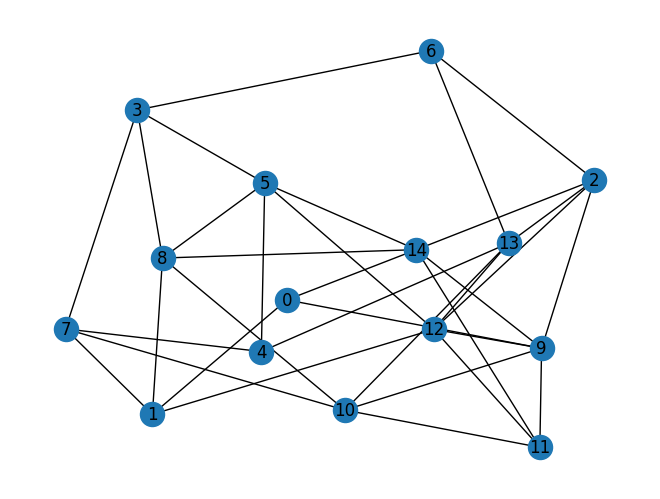

In [26]:
n = 15     # nb nodes
p = 0.2     # edge probability

G = networkx.erdos_renyi_graph(n, p)
networkx.draw(G, with_labels=True)
plt.show()

#It would have been more pertinent to ensure each time that the graph is connected (we need a connected graph !) - Here re-excecute this cell until all points are connected

In [27]:
#Adjency matrix
A=networkx.to_numpy_array(G)
print("Adjency matrix :\r\n"+str(A))

#Degree matrix
D=[[0 for i in range(len(A[0]))] for j in range(len(A[0]))]
for i in range(len(A[0])):
  s=0
  for j in range(len(A[0])):
    s+=A[i][j]
  D[i][i]=s
print("Degree matrix :\r\n"+str(A))

#Laplacian matrix
L=np.subtract(D,A)
print("Laplacian matrix :\r\n"+str(L))

#Weight vector
H=[0 for i in range(n)]
H[0]=1

Adjency matrix :
[[0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 1. 1.]
 [0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1.]
 [0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 1. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1.]
 [1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 1. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 0. 1.]
 [0. 1. 1. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 1. 0.]
 [0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0.]
 [1. 0. 1. 0. 0. 1. 0. 0. 1. 1. 0. 1. 0. 0. 0.]]
Degree matrix :
[[0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 1. 1.]
 [0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0

Normalize your Laplacian, compute its eigen decomposition and verify that L = U.diag(lambda).u^T

Also plot every matrices (U, diag(lambda) and the Laplacian matrix)

In [28]:
#Normalized Laplacian matrix
""" #FAILED ATTEMPT
norm_L=[[0 for i in range(len(L[0]))] for j in range(len(L[0]))]
for i in range(len(L[0])):
  s=0
  for j in range(len(L[0])):
    s+=L[i][j]**2
  for k in range(len(L[0])):
    norm_L[i][k]=L[i][k]/np.sqrt(s)
print("Normalized Laplacian matrix :\r\n "+str(norm_L))
"""
L_norm = networkx.normalized_laplacian_matrix(G).toarray()
print("\r\n\r\nNormalized Laplacian matrix :\r\n "+str(L_norm))

#Eigenvalues of L
eigen_values, eigen_vectors = np.linalg.eig(L_norm)
print("\r\n\r\nEigenvalues :\r\n"+str(eigen_values))

#The spectral Theorem (because L is symetric) ensures L is diagonalizable through a matrix U (and its transpose)
U=eigen_vectors
print("\r\n\r\nU :\r\n"+str(U))

#Verification L= U.diag(lambda).U^t
L_norm_through_U=U @ np.diag(eigen_values) @ np.transpose(U)
for i in range(len(L_norm)):
  for j in range(len(L_norm[0])):
    if 1e-14>=abs(L_norm_through_U[i][j]):
      L_norm_through_U[i][j]=0


print("\r\n\r\nResult of U.diag(lambda).U^t :\r\n"+str(L_norm_through_U))
print("\r\n\r\nAll values below should be equal to 0 if L= U.diag(lambda).U^t:\r\n"+str(np.subtract(L_norm,L_norm_through_U)))



Normalized Laplacian matrix :
 [[ 1.         -0.28867513  0.          0.          0.          0.
   0.          0.          0.         -0.23570226  0.          0.
   0.          0.         -0.23570226]
 [-0.28867513  1.          0.          0.          0.          0.
   0.         -0.25       -0.2236068   0.          0.          0.
  -0.20412415  0.          0.        ]
 [ 0.          0.          1.          0.          0.          0.
  -0.25819889  0.          0.         -0.18257419  0.          0.
  -0.18257419 -0.2        -0.18257419]
 [ 0.          0.          0.          1.          0.         -0.2236068
  -0.28867513 -0.25       -0.2236068   0.          0.          0.
   0.          0.          0.        ]
 [ 0.          0.          0.          0.          1.         -0.25819889
   0.         -0.28867513  0.          0.          0.          0.
   0.         -0.25819889  0.        ]
 [ 0.          0.          0.         -0.2236068  -0.25819889  1.
   0.          0.         -0.2 

* The last matrix tests if L= U*diag(lambda)*U^t, all the values are below 10^-14. It's low enough to consider its good.

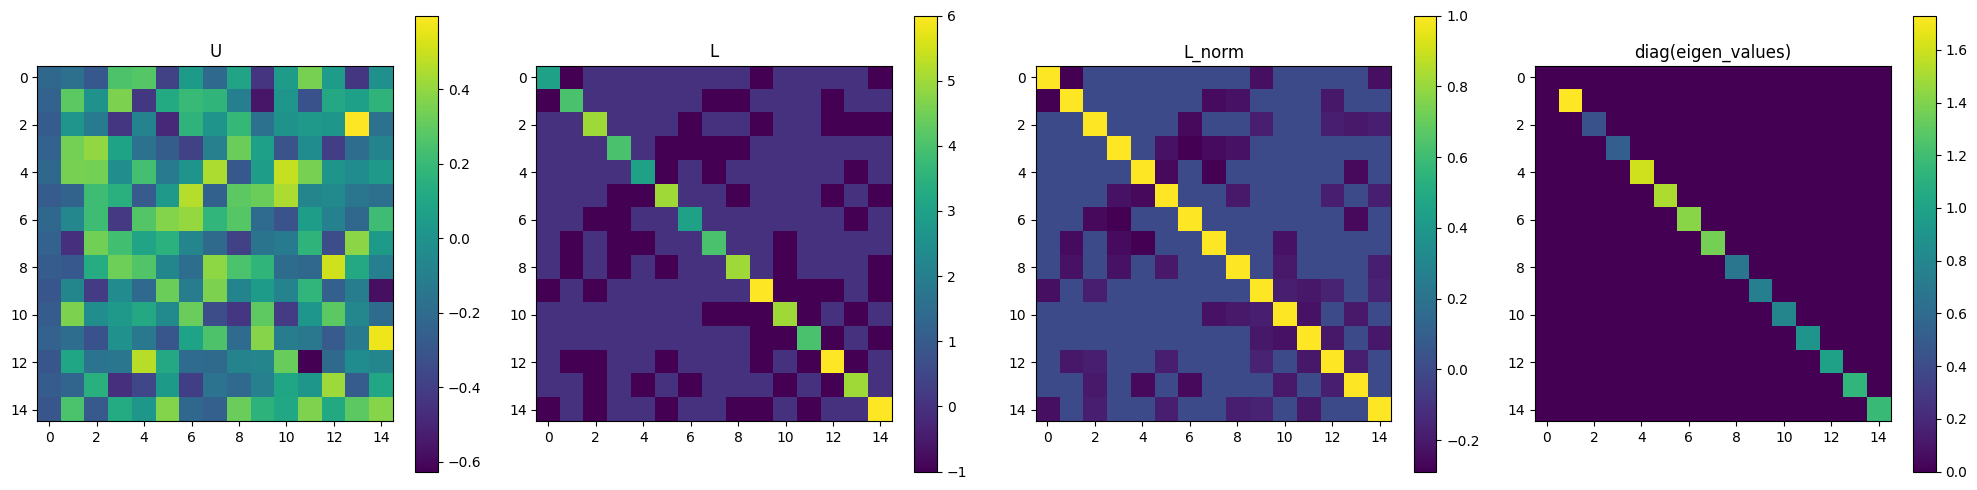

In [29]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# 1. U
im0 = axes[0].imshow(U, cmap="viridis")
axes[0].set_title("U")
plt.colorbar(im0, ax=axes[0])

# 2. L
im1 = axes[1].imshow(L, cmap="viridis")
axes[1].set_title("L")
plt.colorbar(im1, ax=axes[1])

# 3. L_norm
im2 = axes[2].imshow(L_norm, cmap="viridis")
axes[2].set_title("L_norm")
plt.colorbar(im2, ax=axes[2])

# 4. diag(eigen_values)
im3 = axes[3].imshow(np.diag(eigen_values), cmap="viridis")
axes[3].set_title("diag(eigen_values)")
plt.colorbar(im3, ax=axes[3])

plt.tight_layout()
plt.show()


* The L normalisation is used to set all of its diagonal values to 1 (it's normalized by row and column). The values outside the diagonal are weighted on the number of connections of the node (diagonal) - the more the connections has a nodes, the more evenly distributed is the weight accrosed its neighbouring nodes).

Now filter the eigen value with a low-pass filter, a band-pass filter and a high-pass filter. If you're not sure how to do it, since the eigen values are sorted by ascending order, you may only keep the first ones to produce a low-pass filter, the last ones for an high-pass filter and the middle ones for a band-pass filter.

Finally, plot your graph once again by using the drawing functions of networkx, and make appears the signal on the graph for each filtered signal (with the help of the node_color argument for example). You may also use the [nx_agraph.graphviz_layout](https://networkx.org/documentation/stable/reference/generated/networkx.drawing.nx_agraph.graphviz_layout.html) in order to fix the position of your nodes (and thus to have the same plot for each filtered graph).

Explain what you observe.

In [30]:
import numpy as np # Ensure numpy is imported for np.zeros_like

#The eigen values needs first to be sorted (eigh instead of eig)
eigen_values, eigen_vectors = np.linalg.eigh(L_norm)
print("\r\n\r\nEigenvalues :\r\n"+str(eigen_values))

U=eigen_vectors

#print("\r\n\r\nAll values below should be equal to 0 if L= U.diag(lambda).U^t:\r\n"+str(np.subtract(L_norm,U @ np.diag(eigen_values) @ np.transpose(U))))
#works
def filter(eigen_values, beg=0, end=len(eigen_values)): # Changed end default to None for flexibility
  filtered_eig_values = np.zeros_like(eigen_values, dtype=eigen_values.dtype)
  filtered_eig_values[beg:end] = eigen_values[beg:end]
  return filtered_eig_values

# Low-pass filter (keeping the first few eigenvalues)
low_pass_filtered_eigen_values = filter(eigen_values, end=5)
print("\r\nLow-Pass Filtered Eigenvalues:\r\n" + str(low_pass_filtered_eigen_values))

# Band-pass filter (keeping middle eigenvalues)
band_pass_filtered_eigen_values = filter(eigen_values, beg=4, end=10)
print("\r\nBand-Pass Filtered Eigenvalues:\r\n" + str(band_pass_filtered_eigen_values))

# High-pass filter (keeping the last few eigenvalues)
high_pass_filtered_eigen_values = filter(eigen_values, beg=len(eigen_values)-5)
print("\r\nHigh-Pass Filtered Eigenvalues:\r\n" + str(high_pass_filtered_eigen_values))




Eigenvalues :
[2.77099750e-16 4.33691517e-01 5.13748622e-01 6.82413839e-01
 7.47456000e-01 7.89481990e-01 8.95572311e-01 9.87417797e-01
 1.13959286e+00 1.17099775e+00 1.36713499e+00 1.42127839e+00
 1.51798254e+00 1.60290523e+00 1.73032616e+00]

Low-Pass Filtered Eigenvalues:
[2.77099750e-16 4.33691517e-01 5.13748622e-01 6.82413839e-01
 7.47456000e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00]

Band-Pass Filtered Eigenvalues:
[0.         0.         0.         0.         0.747456   0.78948199
 0.89557231 0.9874178  1.13959286 1.17099775 0.         0.
 0.         0.         0.        ]

High-Pass Filtered Eigenvalues:
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         1.36713499 1.42127839
 1.51798254 1.60290523 1.73032616]


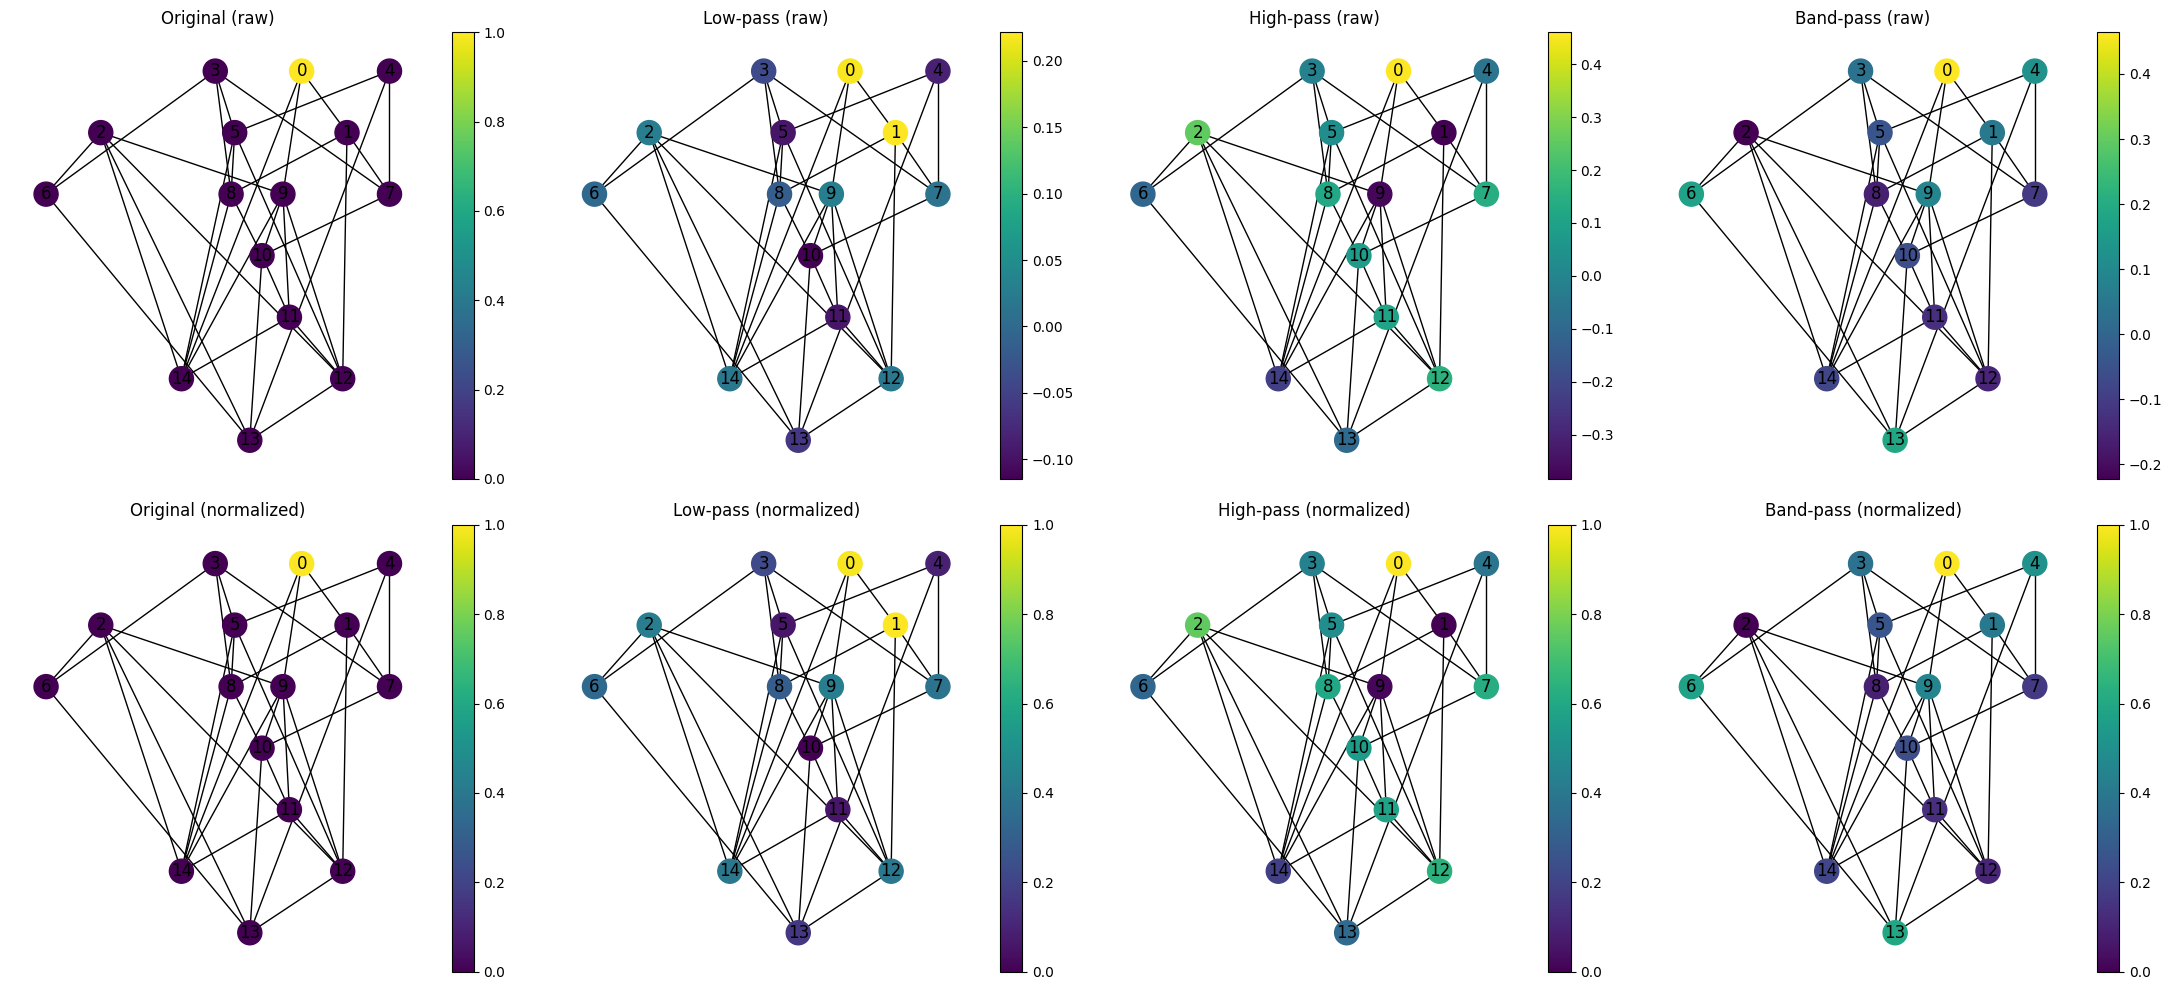

In [32]:
import networkx as nx
from networkx.drawing.nx_agraph import graphviz_layout

pos = graphviz_layout(G, prog="dot")

H = np.array(H)

H_low  = U @ np.diag(low_pass_filtered_eigen_values)  @ U.T @ H
H_high = U @ np.diag(high_pass_filtered_eigen_values) @ U.T @ H
H_band = U @ np.diag(band_pass_filtered_eigen_values) @ U.T @ H

# Normalisation
H_n      = (H      - H.min())      / (H.max()      - H.min())
H_low_n  = (H_low  - H_low.min())  / (H_low.max()  - H_low.min())
H_high_n = (H_high - H_high.min()) / (H_high.max() - H_high.min())
H_band_n = (H_band - H_band.min()) / (H_band.max() - H_band.min())

fig, axes = plt.subplots(2, 4, figsize=(22, 10))

titles_raw = [
    "Original (raw)",
    "Low-pass (raw)",
    "High-pass (raw)",
    "Band-pass (raw)"
]

titles_norm = [
    "Original (normalized)",
    "Low-pass (normalized)",
    "High-pass (normalized)",
    "Band-pass (normalized)"
]

raw_signals = [H, H_low, H_high, H_band]
norm_signals = [H_n, H_low_n, H_high_n, H_band_n]

# Raw graphs
for i in range(4):
    ax = axes[0, i]
    nodes = nx.draw_networkx_nodes(
        G, pos, node_color=raw_signals[i], cmap="viridis",
        node_size=300, ax=ax
    )
    nx.draw_networkx_edges(G, pos, ax=ax)
    nx.draw_networkx_labels(G, pos, ax=ax)
    fig.colorbar(nodes, ax=ax)
    ax.set_title(titles_raw[i])
    ax.axis("off")

# Normalized graphs
for i in range(4):
    ax = axes[1, i]
    nodes = nx.draw_networkx_nodes(
        G, pos, node_color=norm_signals[i], cmap="viridis",
        node_size=300, vmin=0, vmax=1, ax=ax
    )
    nx.draw_networkx_edges(G, pos, ax=ax)
    nx.draw_networkx_labels(G, pos, ax=ax)
    fig.colorbar(nodes, ax=ax)
    ax.set_title(titles_norm[i])
    ax.axis("off")

plt.tight_layout()
plt.show()


* At the end of the day, low-pass, band-pass and high-pass does the thing : they distribute their weight accross their neighbours. The main difference is low pass distribute evently and high-pass tries tries to retain as much as possible weight from its 'giver' node. It's seeable by the fact the weight of 0 (the only 'giver') is divided by 2 from high-pass to low-pass.

* For low-pass it's clear the closer the node is from the giver the higher its weight will be.

* For high-pass, as in the course, the nodes around a giver are the most penalized (also negative) and the others seems instead benefiting.

* Band-pass is a mix of both (ex: the nodes neighbouring the giver have their weight between low-pass and high-pass / the giver retains a lot of its weight)

## Second part : Graph Neural Network

In the second part of the TP, you will code you own GNN an apply them on a toy example, the image seen in course. The code that allow to load the image and transform it into a graph is provided to you by the following code. You may find the images on Moodle.

In [5]:
from PIL import Image
import numpy as np

def from_image_to_graph(path_image):
    image = Image.open(path_image)
    im = np.asarray(image)
    row, col = np.shape(im)
    adjacency = np.zeros((row*col, row*col))
    for i in range(row):
        for j in range(col):
            if i > 0:
                if j > 0:
                    adjacency[i * row + j, (i - 1) * row + j - 1] = 1
                adjacency[i * row + j, (i - 1) * row + j] = 1
                if j < col-1:
                    adjacency[i * row + j, (i - 1) * row + j + 1] = 1
            if j > 0 :
                adjacency[i * row + j, i * row + j - 1] = 1
            if j < col-1:
                adjacency[i * row + j, i * row + j + 1] = 1
            if i < row-1 :
                if j > 0:
                    adjacency[i * row + j, (i + 1) * row + j - 1] = 1
                adjacency[i * row + j, (i + 1) * row + j] = 1
                if j < col-1:
                    adjacency[i * row + j, (i + 1) * row + j + 1] = 1
    nodes = []
    for i in range(row):
        nodes = np.concatenate((nodes, im[i,:]))
    nodes = nodes/255

    return nodes, adjacency


You are now going to compute your own Graph Neural Network. For Deep Learning, you may find 2 different libraries in Python : [TensorFlow](https://www.tensorflow.org/?hl=fr) and [PyTorch](https://pytorch.org/). Both of them are based on tensors operations. In general, PyTorch is a little bit simpler to use, and it is probably the most used library between the two of them, mostly in reasearch and development, while TensorFlow is more efficient and scalable but is more demanding in terms of programming. For this TP, you may use either TensorFlow and PyTorch with PyTorch being recommanded. The instructions and advices given in the rest of the TP are mostly designed for PyTorch, but both are pretty similar. Also, for Graph Neural Networks, there is [PyTorch-Geometric](https://pytorch-geometric.readthedocs.io/en/latest/), but it requires to know PyTorch first.

Whatever your choice, develop you own layer and implement a vanilla Graph Neural Network. For TensorFlow, you may find an example on how to implement your own layer [here](https://www.tensorflow.org/api_docs/python/tf/keras/Layer), and for PyTorch, you may go [there](https://pytorch.org/tutorials/recipes/recipes/defining_a_neural_network.html).

As a reminder, the formula for the vanilla GNN is $H^{l+1} = \sigma(AH^lW^l+b^l)$

For the PyTorch users, you can use the [nn](https://pytorch.org/docs/stable/nn.html) module, and define a class that extends the nn.Module class. In this class, you can define the different layers you need in the \_\_init\_\_() function. In our case, you need to define 2 [nn.Linear](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) layers : one for the GNN, and one for the decision. These layers require 2 arguments : the size of input features, and the size of output features. According to your knowledge, determine both of them.

If the \_\_init\_\_() is used to define the different layers that you need, the forward function is used to define how they are used. This function is pretty simple and straight forward : you reproduce the formula of the vanilla GNN inside. You thus need a matrix multiplication function (torch.matmul) and the linear function make the rest. We won't use the activation function $\sigma$ for the moment.


In [6]:
from google.colab import files
uploaded = files.upload()
!tar -xvf images.tar.xz
!ls -R

Saving images.tar.xz to images.tar (2).xz
band_pass.png
high_pass.png
input.png
low_pass.png
.:
 band_pass.png	'images.tar (1).xz'   images.tar.xz   low_pass.png
 high_pass.png	'images.tar (2).xz'   input.png       sample_data

./sample_data:
anscombe.json		      mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md


The following code is how I first envisionned the neural network

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
#The image is composed of nuance of grey (no RGB)
nodes, adjacency=from_image_to_graph("/content/input.png")
#Conversion to tensor
C= torch.tensor(np.identity(len(adjacency))+adjacency,dtype=torch.float32)
A = torch.tensor(adjacency, dtype=torch.float32) #H_0
nodes = torch.tensor(nodes, dtype=torch.float32).reshape(-1,1)
#First and Second propagation
H0 = A@nodes
H1 = C@H0
#Defining layers
lin1 = nn.Linear(H1.shape[1], H1.shape[1])
lin2 = nn.Linear(H1.shape[1], H1.shape[1]) #same size as nodes
#Prediction
y_pred_beg = lin1(H1)
y_pred= lin2(y_pred_beg)

"""
#Inspired from https://docs.pytorch.org/tutorials/recipes/recipes/defining_a_neural_network.html
class Net(nn.Module):
    def __init__(self): #when creating my_nn this get automacticly called
      super(Net, self).__init__()

      # First fully connected layer
      self.fc1 = nn.Linear(9216, 128)
      # Second fully connected layer that outputs our 10 labels
      self.fc2 = nn.Linear(128, 10)

my_nn = Net() #my_nn IS the neural network
print(my_nn)
"""


'\n#Inspired from https://docs.pytorch.org/tutorials/recipes/recipes/defining_a_neural_network.html\nclass Net(nn.Module):\n    def __init__(self): #when creating my_nn this get automacticly called\n      super(Net, self).__init__()\n\n      # First fully connected layer\n      self.fc1 = nn.Linear(9216, 128)\n      # Second fully connected layer that outputs our 10 labels\n      self.fc2 = nn.Linear(128, 10)\n\nmy_nn = Net() #my_nn IS the neural network\nprint(my_nn)\n'

Now that your model has been defined, you will train your model with only one data : the original image as the input and the filtered image as the output. Instead of generalizing, as we expect when we are doing Machine Learning, we thus want to specialize, and to learn to produce the same output everytime.

In both TensorFlow and PyTorch, you need to define at least three things : an instance of your model the optimizer and the loss function.

The optimizer is the function that allow to find the best weight for the model, while the loss function define what "best" is.

For the loss function, since we are working on a regression problem you will use the Mean Squared Error Loss, and the Adam optimizer.

Finally, load your data and train your model by iterating it n times, and updating the weight each time. Check [here](https://pytorch.org/tutorials/beginner/basics/optimization_tutorial.html) to have an example.

Plot the resulting images and conclude.

---
The plan is the following :

* We want to prepare 3 neural networks that uses Vanilla GNN logic as a band-pass, low-pass and high-pass. The neural network will find the best weights and biaises for the Vanilla GNN formula that will fit the result we're looking for. (It's implied this research will be possible).

**My CODE**

100%|██████████| 200/200 [00:09<00:00, 21.16it/s]


Loss low: 0.00406979862600565
Loss high: 0.0030501075088977814
Loss band: 0.008728740736842155


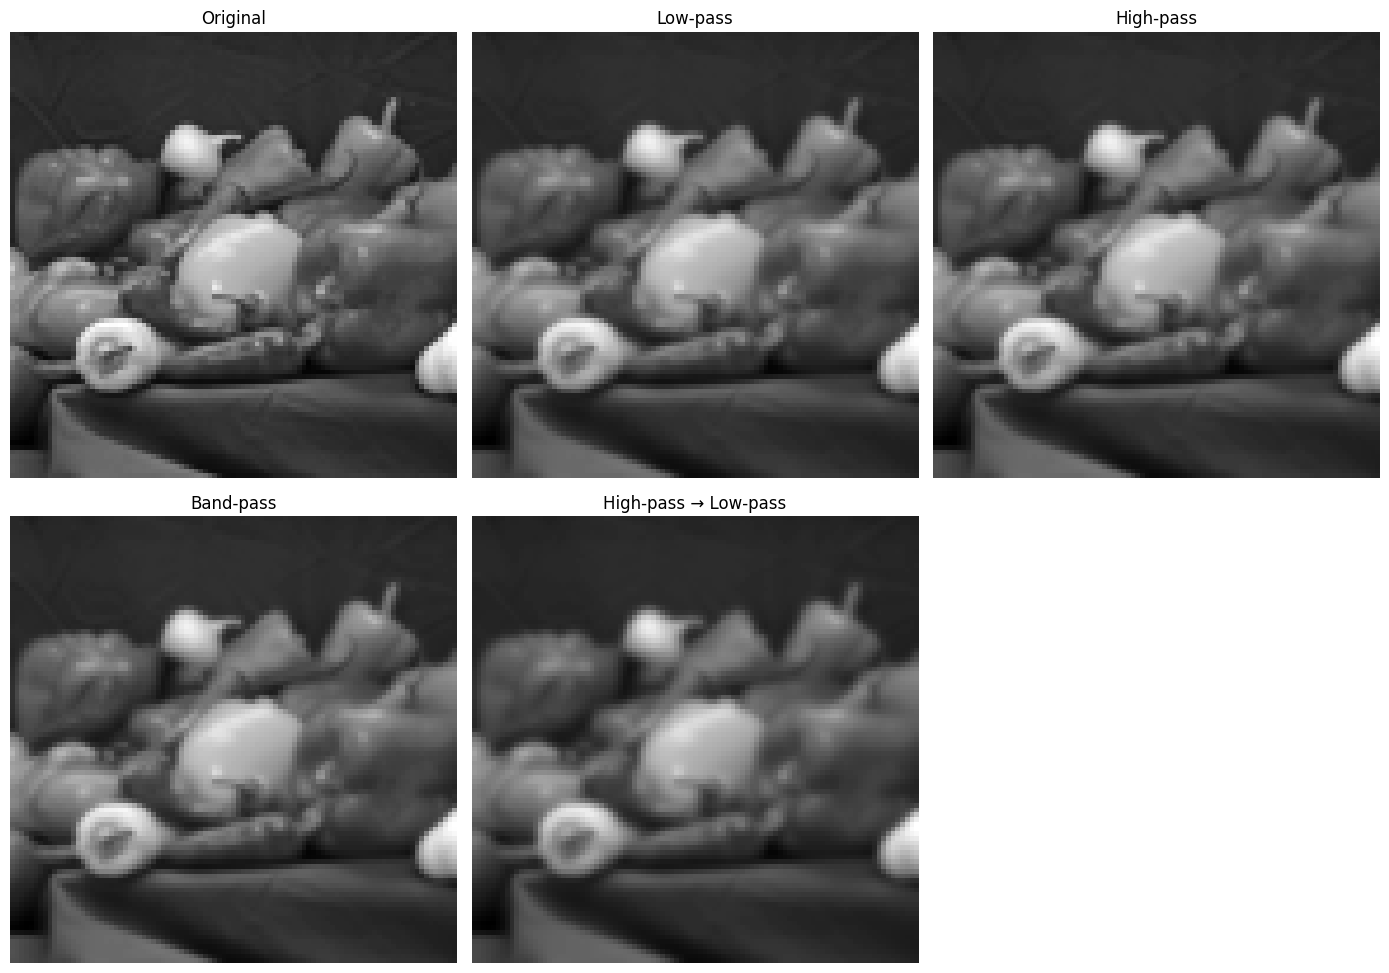

In [31]:
import time
from tqdm import tqdm
import torch
import torch.nn as nn


#This function trains our neural network
def train_gnn(A, C, X, Y_target, lin1, lin2, lr=0.07, num_epochs=200, pas_min=1e-5):
    optimizer = torch.optim.SGD(list(lin1.parameters()) + list(lin2.parameters()), lr=lr)
    loss_fn = nn.MSELoss()

    history = []
    start = time.time()

    for epoch in tqdm(range(num_epochs)):
        H = C @ X
        H = lin1(H)
        Y_pred = lin2(H)
        #Y_pred = torch.sigmoid(Y_pred)

        loss = loss_fn(Y_pred, Y_target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        history.append(loss.item())

        if loss.item() < pas_min:
            break

    end = time.time()
    return history, end - start, Y_pred


# Must normalize to get good results
nodes_np, adjacency = from_image_to_graph("/content/input.png")

A = torch.tensor(adjacency, dtype=torch.float32)

deg = A.sum(dim=1, keepdim=True)
A_norm = A / deg

C = torch.eye(A.size(0)) + A_norm

X = torch.tensor(nodes_np, dtype=torch.float32).reshape(-1, 1)

input_image_raw = Image.open("/content/input.png")
input_image_array = np.asarray(input_image_raw)
row, col = np.shape(input_image_array)


y_low_np  = from_image_to_graph("/content/low_pass.png")[0]
y_high_np = from_image_to_graph("/content/high_pass.png")[0]
y_band_np = from_image_to_graph("/content/band_pass.png")[0]

y_low  = torch.tensor(y_low_np,  dtype=torch.float32).reshape(-1, 1)
y_high = torch.tensor(y_high_np, dtype=torch.float32).reshape(-1, 1)
y_band = torch.tensor(y_band_np, dtype=torch.float32).reshape(-1, 1)

# Took 32 because seemed the best one
n=32
lin1_low  = nn.Linear(1, n)
lin2_low  = nn.Linear(n, 1)

lin1_high = nn.Linear(1, n)
lin2_high = nn.Linear(n, 1)

lin1_band = nn.Linear(1, n)
lin2_band = nn.Linear(n, 1)


hist_low,  t_low,  y_pred_low  = train_gnn(A_norm, C, X, y_low,  lin1_low,  lin2_low)
hist_high, t_high, y_pred_high = train_gnn(A_norm, C, X, y_high, lin1_high, lin2_high)
hist_band, t_band, y_pred_band = train_gnn(A_norm, C, X, y_band, lin1_band, lin2_band)

print("Loss low:", hist_low[-1])
print("Loss high:", hist_high[-1])
print("Loss band:", hist_band[-1])


with torch.no_grad():
  X_high = y_pred_high.detach()
  H = C @ X_high
  H = lin1_low(H)
  H = torch.relu(H)
  y_pred_high_then_low = lin2_low(H)


def reconstruct_image(y_pred, row, col):
    return y_pred.detach().numpy().reshape(row, col)

img_high_then_low = reconstruct_image(y_pred_high_then_low, row, col)
img_low  = reconstruct_image(y_pred_low,  row, col)
img_high = reconstruct_image(y_pred_high, row, col)
img_band = reconstruct_image(y_pred_band, row, col)


input_image = nodes_np.reshape(row, col)

plt.figure(figsize=(14, 10))

plt.subplot(2, 3, 1)
plt.imshow(input_image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(img_low, cmap="gray")
plt.title("Low-pass")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(img_high, cmap="gray")
plt.title("High-pass")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(img_band, cmap="gray")
plt.title("Band-pass")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(img_high_then_low, cmap="gray")
plt.title("High-pass → Low-pass")
plt.axis("off")

plt.tight_layout()
plt.show()



The result are underwhelming, all of the filters seems to act as a weak low pass despite having clearly different images to imitate. The worst is this is the solution I have found where the filters loss function are the lowest.

Modelizing the distance between the filters as a convex function seems not coherent. For instance, modyfying the learning rate and even sometimes the number of iterations (epochs) can sometimes : make the image more contrasted (for high pass), make it evently black, make it reverse its colors, or a mix of these situations.

The band pass (made from the two filter) acts as the strongest low pass (seen by stronger blur) because we apply 2 times the 'same' filter.

100%|██████████| 50/50 [01:30<00:00,  1.81s/it]


Loss low: 0.0457124188542366
Loss high: 0.003670365083962679
Loss band: 0.00885814055800438


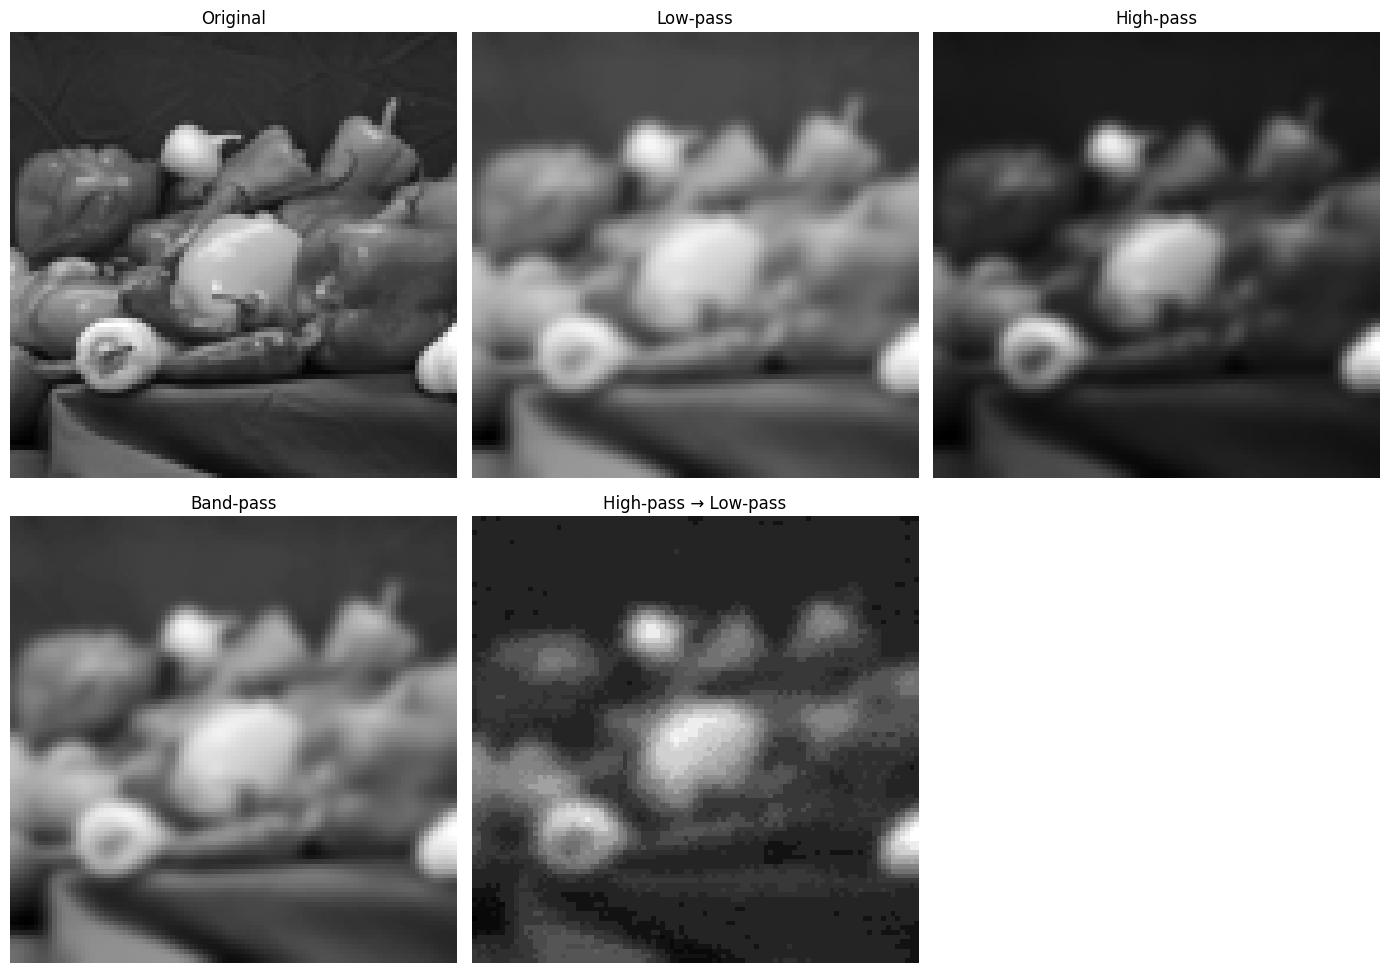

In [35]:
import time
from tqdm import tqdm
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


def train_gnn(A, C, X, Y_target, layers, lr=0.00001, num_epochs=50, pas_min=1e-6):
    params = []
    for lin in layers:
        params += list(lin.parameters())

    optimizer = torch.optim.SGD(params, lr=lr)
    loss_fn = nn.MSELoss()

    history = []
    start = time.time()

    for epoch in tqdm(range(num_epochs)):

        H = X.clone()

        for lin in layers[:-1]:
            H = C @ H
            H = lin(H)
            H = torch.nn.functional.softsign(H)
            H = (H + 1) / 2
        H = C @ H
        Y_pred = layers[-1](H)
        Y_pred = torch.sigmoid(Y_pred)

        loss = loss_fn(Y_pred, Y_target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        history.append(loss.item())

        if loss.item() < pas_min:
            break

    end = time.time()
    return history, end - start, Y_pred



nodes_np, adjacency = from_image_to_graph("/content/input.png")

A = torch.tensor(adjacency, dtype=torch.float32)

deg = A.sum(dim=1, keepdim=True)
A_norm = A / deg

C = torch.eye(A.size(0)) + A_norm

X = torch.tensor(nodes_np, dtype=torch.float32).reshape(-1, 1)


input_image_raw = Image.open("/content/input.png")
input_image_array = np.asarray(input_image_raw)
row, col = np.shape(input_image_array)


y_low_np  = from_image_to_graph("/content/low_pass.png")[0]
y_high_np = from_image_to_graph("/content/high_pass.png")[0]
y_band_np = from_image_to_graph("/content/band_pass.png")[0]

y_low  = torch.tensor(y_low_np,  dtype=torch.float32).reshape(-1, 1)
y_high = torch.tensor(y_high_np, dtype=torch.float32).reshape(-1, 1)
y_band = torch.tensor(y_band_np, dtype=torch.float32).reshape(-1, 1)


n = 32

def build_10_layers():
    layers = []
    layers.append(nn.Linear(1, n))
    for _ in range(3):
        layers.append(nn.Linear(n, n))
    layers.append(nn.Linear(n, 1))
    return layers

layers_low  = build_10_layers()
layers_high = build_10_layers()
layers_band = build_10_layers()


hist_low,  t_low,  y_pred_low  = train_gnn(A_norm, C, X, y_low,  layers_low)
hist_high, t_high, y_pred_high = train_gnn(A_norm, C, X, y_high, layers_high)
hist_band, t_band, y_pred_band = train_gnn(A_norm, C, X, y_band, layers_band)

print("Loss low:", hist_low[-1])
print("Loss high:", hist_high[-1])
print("Loss band:", hist_band[-1])


with torch.no_grad():
    X_high = y_pred_high.detach()
    H = X_high.clone()
    for lin in layers_low[:-1]:
        H = C @ H
        H = lin(H)
        H = torch.nn.functional.softsign(H)
        H = (H + 1) / 2
    H = C @ H
    y_pred_high_then_low = torch.sigmoid(layers_low[-1](H))


def reconstruct_image(y_pred, row, col):
    return y_pred.detach().numpy().reshape(row, col)

img_high_then_low = reconstruct_image(y_pred_high_then_low, row, col)
img_low  = reconstruct_image(y_pred_low,  row, col)
img_high = reconstruct_image(y_pred_high, row, col)
img_band = reconstruct_image(y_pred_band, row, col)

input_image = nodes_np.reshape(row, col)

plt.figure(figsize=(14, 10))

plt.subplot(2, 3, 1)
plt.imshow(input_image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(img_low, cmap="gray")
plt.title("Low-pass")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(img_high, cmap="gray")
plt.title("High-pass")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(img_band, cmap="gray")
plt.title("Band-pass")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(img_high_then_low, cmap="gray")
plt.title("High-pass → Low-pass")
plt.axis("off")

plt.tight_layout()
plt.show()



This test confirms that :
* The local lowest point is not necessarily the best.
* The highest number of layers, the stronger the filter (then the blur)

All the images have the same blur and vary on how they handle contrast (softsign and sigmoid are used to see if it does improve the filters - It has an effect on the high-pass, making it more gray).

Loss low: 0.0379897803068161
Loss high: 0.003323865821585059
Loss band: 0.008893599733710289


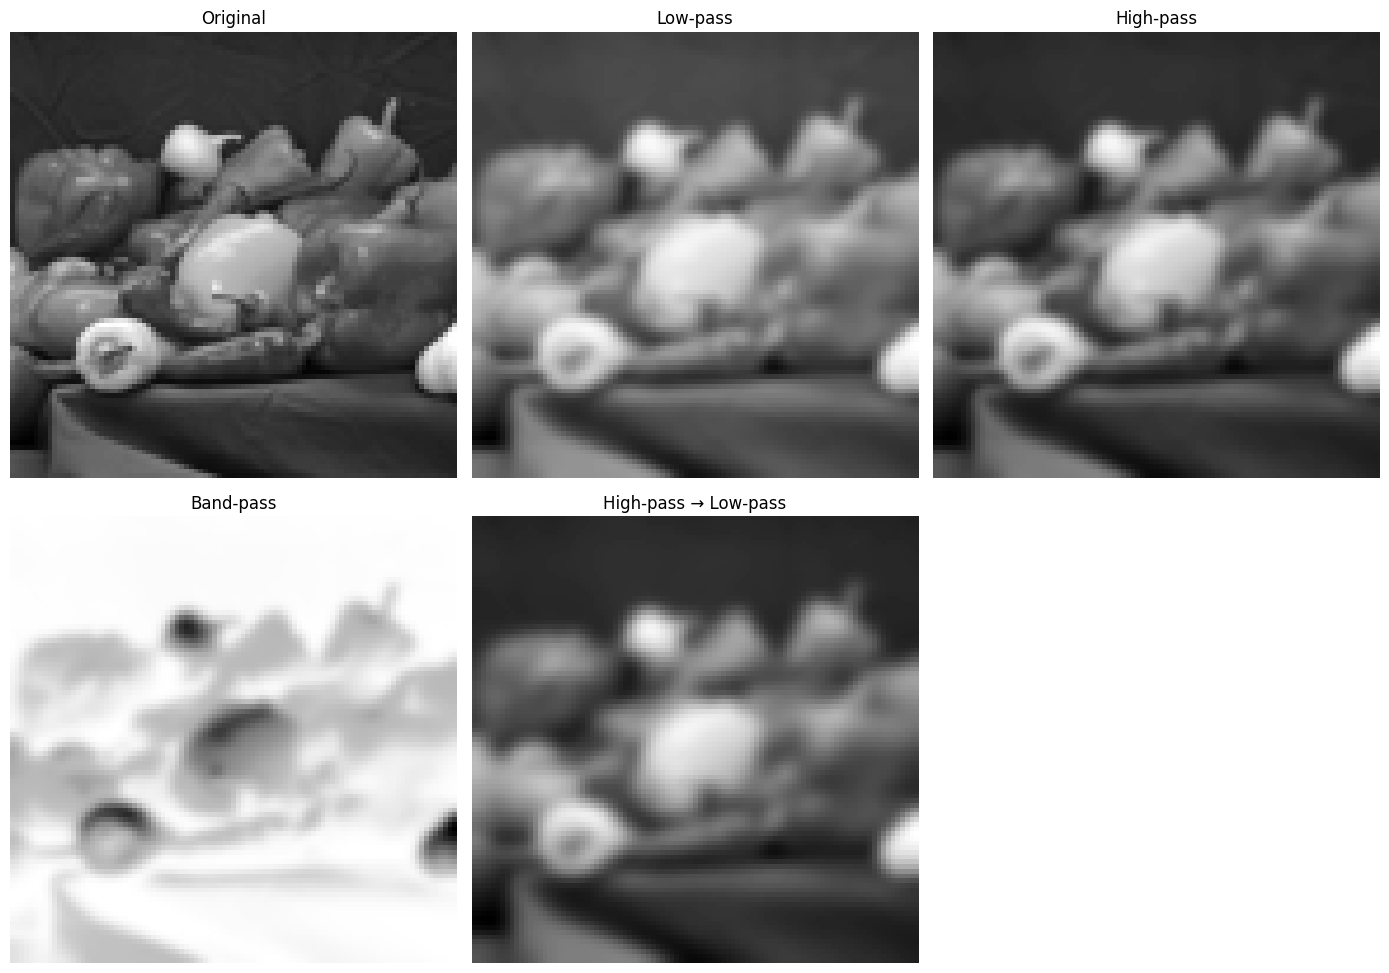

In [36]:
import time
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


def reconstruct_image(y_pred, row, col):
    return y_pred.detach().cpu().numpy().reshape(row, col)


def train_gnn(A_norm, C, X, Y_target, layers, U, alpha=0.3, lr=0.001, num_epochs=60, pas_min=1e-5):

    params = []
    for lin in layers:
        params += list(lin.parameters())

    optimizer = torch.optim.Adam(params, lr=lr)
    loss_mse = nn.MSELoss()

    history = []
    start = time.time()

    U_t = U.T

    for epoch in range(num_epochs):
        H = X
        for lin in layers[:-1]:
            H = C @ H
            H = lin(H)
            H = torch.nn.functional.softsign(H)
            H = (H + 1) / 2

        H = C @ H
        Y_pred = torch.sigmoid(layers[-1](H))

        loss_spatial = loss_mse(Y_pred, Y_target)

        Yp_hat = U_t @ Y_pred
        Yt_hat = U_t @ Y_target
        loss_spectral = loss_mse(Yp_hat, Yt_hat)

        loss = alpha * loss_spatial + (1 - alpha) * loss_spectral

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        history.append(loss.item())

        if loss.item() < pas_min:
            break

    return history, time.time() - start, Y_pred


nodes_np, adjacency = from_image_to_graph("/content/input.png")

A = torch.tensor(adjacency, dtype=torch.float32)

deg = A.sum(dim=1, keepdim=True)
A_norm = A / deg
C = torch.eye(A.size(0)) + A_norm

X = torch.tensor(nodes_np, dtype=torch.float32).reshape(-1, 1)

input_image_raw = Image.open("/content/input.png")
input_image_array = np.asarray(input_image_raw)
row, col = np.shape(input_image_array)


y_low_np  = from_image_to_graph("/content/low_pass.png")[0]
y_high_np = from_image_to_graph("/content/high_pass.png")[0]
y_band_np = from_image_to_graph("/content/band_pass.png")[0]

y_low  = torch.tensor(y_low_np,  dtype=torch.float32).reshape(-1, 1)
y_high = torch.tensor(y_high_np, dtype=torch.float32).reshape(-1, 1)
y_band = torch.tensor(y_band_np, dtype=torch.float32).reshape(-1, 1)


adj_np = adjacency.astype(np.float32)
deg_np = adj_np.sum(axis=1)
L_np = np.diag(deg_np) - adj_np

eigvals, U_np = np.linalg.eigh(L_np)
U = torch.tensor(U_np, dtype=torch.float32)


n = 32

def build_layers():
    return [
        nn.Linear(1, n),
        nn.Linear(n, n),
        nn.Linear(n, n),
        nn.Linear(n, 1)
    ]

layers_low  = build_layers()
layers_high = build_layers()
layers_band = build_layers()


hist_low,  t_low,  y_pred_low  = train_gnn(A_norm, C, X, y_low,  layers_low,  U, alpha=0.3)
hist_high, t_high, y_pred_high = train_gnn(A_norm, C, X, y_high, layers_high, U, alpha=0.7)
hist_band, t_band, y_pred_band = train_gnn(A_norm, C, X, y_band, layers_band, U, alpha=0.5)

print("Loss low:",  hist_low[-1])
print("Loss high:", hist_high[-1])
print("Loss band:", hist_band[-1])

# High + Low filter

with torch.no_grad():
    H = y_pred_high
    for lin in layers_low[:-1]:
        H = C @ H
        H = lin(H)
        H = torch.nn.functional.softsign(H)
        H = (H + 1) / 2
    H = C @ H
    y_pred_high_then_low = torch.sigmoid(layers_low[-1](H))


img_high_then_low = reconstruct_image(y_pred_high_then_low, row, col)
img_low  = reconstruct_image(y_pred_low,  row, col)
img_high = reconstruct_image(y_pred_high, row, col)
img_band = reconstruct_image(y_pred_band, row, col)

input_image = nodes_np.reshape(row, col)

plt.figure(figsize=(14, 10))

plt.subplot(2, 3, 1)
plt.imshow(input_image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(img_low, cmap="gray")
plt.title("Low-pass")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(img_high, cmap="gray")
plt.title("High-pass")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(img_band, cmap="gray")
plt.title("Band-pass")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(img_high_then_low, cmap="gray")
plt.title("High-pass → Low-pass")
plt.axis("off")

plt.tight_layout()
plt.show()



The loss function has been modified to include the spectral and spatial loss. I've done so to see if it would make the local minimum lower but the other effects (sigmoid/softsign/number of layers) are very prominent. The high pass filter seems to be more contrasted which is what we seek to (the high filter is uniformly gray with only the contours seeable -> high intensity gradient area).



---
Do not excecute the following code
The reason why we don't reuse the spectral method is because of time (computing on a 100x100 matrix isn't a good idea). In theory though it should be better.
